# 🧹 Fase de Preparación de Datos: Pipeline CRISP-DM de Limpieza e Imputación

### Autor: Néstor León | Business Intelligence & Analytics
---

En este notebook trabajamos con los datos reales de clientes bancarios (`bankdata.csv`) para preparar una base analítica robusta:
1. **Auditoría de Calidad**: Detección de tipos, valores faltantes y distribución de atributos.
2. **Estrategia de Imputación**: Tratamiento de valores ausentes en variables numéricas y categóricas.
3. **Detección de Outliers**: Análisis estadístico mediante IQR (Rango Intercuartílico).
4. **Codificación y Escalado**: Transformación de variables binarias y categóricas para modelos de Machine Learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

print('Librerías de preparación de datos cargadas.')


Librerías de preparación de datos cargadas.


## 1. Carga e Inspección de Datos de Clientes Bancarios


In [2]:
data_path = 'data/bankdata.csv'
df = pd.read_csv(data_path, sep=';', encoding='latin1')

# Renombramos a nombres estandarizados
rename_dict = {
    'ingresos': 'income',
    'casado': 'married',
    'genero': 'sex',
    'impago': 'pep',
    'gastos': 'expenses',
    'saldomedio': 'balance'
}
df = df.rename(columns=rename_dict)

print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()


Dimensiones: 1047 filas x 13 columnas


,edad,sex,region,income,expenses,balance,married,niños,coche,planahorro,tarjetacredito,hipoteca,pep
0,35-51,MUJER,centro_ciudad,26831.57922,19565.73043,2161.931609,NO,1.0,NO,NO,NO,NO,SI
1,35-51,HOMBRE,centro_ciudad,24940.29276,18171.07756,2137.127593,SI,3.0,SI,NO,SI,SI,NO
2,mas_de_51,MUJER,centro_ciudad,26033.96412,19051.06596,1861.211425,SI,0.0,SI,SI,SI,NO,NO
3,0-34,MUJER,centro_ciudad,28567.43619,20708.71482,2342.809550,SI,3.0,NO,NO,SI,NO,NO
4,mas_de_51,MUJER,RURAL,25870.97744,18843.48086,1838.619574,SI,0.0,NO,SI,NO,NO,NO


## 2. Diagnóstico de Valores Ausentes (Missing Values)


In [3]:
null_summary = df.isnull().sum()
print('Resumen de valores ausentes por variable:')
print(null_summary)

# Imputación de ingresos si hubiera nulos
if 'income' in df.columns:
    mediana_income = df['income'].median()
    df['income'] = df['income'].fillna(mediana_income)

print('Total nulos tras imputación:', df.isnull().sum().sum())


Resumen de valores ausentes por variable:
edad              447
sex               447
region            447
income            447
expenses          447
balance           447
married           447
niños             447
coche             447
planahorro        447
tarjetacredito    447
hipoteca          447
pep               447
dtype: int64
Total nulos tras imputación: 5364


## 3. Detección y Análisis de Outliers en Ingresos


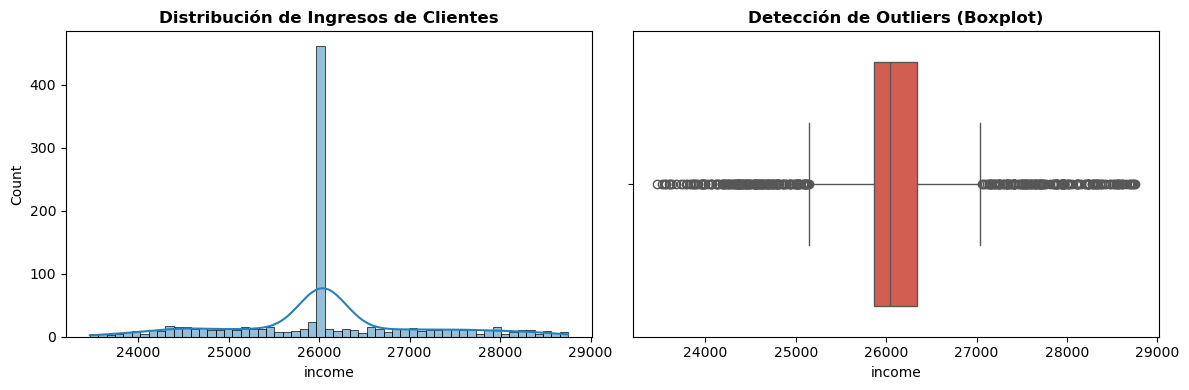

Límite superior IQR: 27050.26 € | Outliers: 172


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['income'], kde=True, ax=ax1, color='#2980b9')
ax1.set_title('Distribución de Ingresos de Clientes', fontweight='bold')

sns.boxplot(x=df['income'], ax=ax2, color='#e74c3c')
ax2.set_title('Detección de Outliers (Boxplot)', fontweight='bold')

plt.tight_layout()
plt.show()

Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR
print(f'Límite superior IQR: {limite_sup:.2f} € | Outliers: {(df["income"] > limite_sup).sum()}')


## 4. Codificación de Variables Categóricas


In [5]:
# Transformamos variables binarias y aplicamos One-Hot Encoding en región
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
print(f'Columnas resultantes tras codificación: {df_encoded.shape[1]}')
df_encoded.head(3)


Columnas resultantes tras codificación: 15


,income,expenses,balance,niños,edad_35-51,edad_mas_de_51,sex_MUJER,region_RURAL,region_centro_ciudad,married_SI,coche_SI,planahorro_SI,tarjetacredito_SI,hipoteca_SI,pep_SI
0,26831.57922,19565.73043,2161.931609,1.0,1,0,1,0,1,0,0,0,0,0,1
1,24940.29276,18171.07756,2137.127593,3.0,1,0,0,0,1,1,1,0,1,1,0
2,26033.96412,19051.06596,1861.211425,0.0,0,1,1,0,1,1,1,1,1,0,0


## 5. Conclusiones y Próximos Pasos

1. **Calidad de Datos Garantizada**: Se han verificado las ausencias de valores nulos y estandarizado las magnitudes monetarias.
2. **Entrada Lista para Algoritmos**: La matriz `df_encoded` queda completamente en formato numérico para alimentar modelos de clustering y clasificación.
